# Phase 1c — Multi-Stock: BBCA & BBRI

## Apa yang kita lakukan di sini?

Di Phase 1a dan 1b, kita sudah punya model AAPL yang solid dengan konfigurasi terbaik:
- Sequence length: **90 hari**
- Arsitektur: **Medium (LSTM 128 → 64)**
- Dropout: **0.1**
- MAPE: **1.34%**

Sekarang kita replikasi konfigurasi yang sama ke **BBCA** dan **BBRI** — dua saham Indonesia dari notebook lama kamu.

## Kenapa saham Indonesia lebih tricky?

BBCA dan BBRI itu beda karakteristiknya dari AAPL:

| Aspek | AAPL (US) | BBCA / BBRI (IDX) |
|-------|-----------|-------------------|
| Mata uang | USD | IDR (Rupiah) |
| Harga per lembar | ~$200 | ~Rp 8.000 - 9.000 |
| Jam trading | NYSE: 09:30–16:00 ET | IDX: 09:00–15:00 WIB |
| Liquidity | Sangat tinggi | Tinggi tapi lebih rendah |
| Pengaruh eksternal | Global tech sentiment | IHSG, kebijakan BI, nilai tukar USD/IDR |

Karena perbedaan ini, **setiap saham punya model sendiri** — bukan satu model untuk semua.
Model yang bagus untuk AAPL belum tentu sama persis hasilnya untuk BBCA.

## Output notebook ini

Di akhir, kamu akan punya **3 model tersimpan**:
- `AAPLstock_price_prediction_model_v3.keras` — dari Phase 1b
- `BBCAstock_price_prediction_model_v1.keras` — dari notebook ini
- `BBRIstock_price_prediction_model_v1.keras` — dari notebook ini

---
## Bagian 1 — Setup

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import ta
import yfinance as yf
import joblib, json

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping

sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')
%matplotlib inline

tf.random.set_seed(42)
np.random.seed(42)

# ============================================================
# KONFIGURASI TERBAIK DARI PHASE 1b
# Kita pakai konfigurasi ini untuk semua saham
# ============================================================
BEST_CONFIG = {
    'sequence_length': 90,       # 90 hari window
    'lstm_units'     : (128, 64), # Medium architecture
    'dropout'        : 0.1,       # regularisasi ringan
    'batch_size'     : 32,
    'epochs'         : 50,
}

FEATURES = [
    'Close', 'Volume', 'RSI', 'MACD', 'MACD_Signal',
    'BB_Width', 'SMA_20', 'SMA_50', 'Volume_Ratio', 'Daily_Return'
]

# Periode data — dari 2020 sampai hari ini
START = datetime(2020, 1, 1)
END   = datetime.today()

print('Setup selesai.')
print(f'Konfigurasi yang dipakai: {BEST_CONFIG}')

Setup selesai.
Konfigurasi yang dipakai: {'sequence_length': 90, 'lstm_units': (128, 64), 'dropout': 0.1, 'batch_size': 32, 'epochs': 50}


---
## Bagian 2 — Helper functions

Sama seperti Phase 1b, kita bungkus semua langkah ke dalam fungsi.
Bedanya sekarang ada fungsi `run_full_pipeline` yang menggabungkan semuanya —
download data, feature engineering, training, evaluasi, dan simpan model —
dalam satu panggilan fungsi.

Dengan ini, menambah saham baru tinggal **satu baris kode**.

In [2]:
def download_and_engineer(ticker, start, end):
    """
    Download data saham dan hitung semua technical indicators.
    Sama persis dengan Phase 1a & 1b, tapi sekarang ticker bisa diganti.
    """
    print(f'  Downloading {ticker}...', end=' ')
    raw = yf.download(ticker, start=start, end=end, auto_adjust=False, progress=False)

    if len(raw) == 0:
        raise ValueError(f'Data untuk {ticker} tidak ditemukan. Cek ticker-nya.')

    # Susun DataFrame
    # Catatan: yfinance untuk saham IDX kadang tidak pakai MultiIndex
    # jadi kita handle dua kemungkinan
    df = pd.DataFrame()
    try:
        # Coba MultiIndex dulu (seperti AAPL di Phase 1a)
        df['Close']  = raw['Close'][ticker]
        df['High']   = raw['High'][ticker]
        df['Low']    = raw['Low'][ticker]
        df['Open']   = raw['Open'][ticker]
        df['Volume'] = raw['Volume'][ticker]
    except (KeyError, TypeError):
        # Fallback: akses langsung (single ticker download)
        df['Close']  = raw['Close']
        df['High']   = raw['High']
        df['Low']    = raw['Low']
        df['Open']   = raw['Open']
        df['Volume'] = raw['Volume']

    # Hitung technical indicators
    df['RSI'] = ta.momentum.RSIIndicator(df['Close'], window=14).rsi()

    macd_obj = ta.trend.MACD(df['Close'], window_fast=12, window_slow=26, window_sign=9)
    df['MACD']        = macd_obj.macd()
    df['MACD_Signal'] = macd_obj.macd_signal()
    df['MACD_Hist']   = macd_obj.macd_diff()

    bb_obj = ta.volatility.BollingerBands(df['Close'], window=20, window_dev=2)
    df['BB_Upper']  = bb_obj.bollinger_hband()
    df['BB_Middle'] = bb_obj.bollinger_mavg()
    df['BB_Lower']  = bb_obj.bollinger_lband()
    df['BB_Width']  = (df['BB_Upper'] - df['BB_Lower']) / df['BB_Middle']

    df['SMA_20'] = ta.trend.SMAIndicator(df['Close'], window=20).sma_indicator()
    df['SMA_50'] = ta.trend.SMAIndicator(df['Close'], window=50).sma_indicator()

    df['Volume_Ratio'] = df['Volume'] / df['Volume'].rolling(20).mean()
    df['Daily_Return'] = df['Close'].pct_change()

    df.dropna(inplace=True)

    print(f'{len(df)} hari data ({df.index[0].date()} — {df.index[-1].date()})')
    return df


def prepare_data(df, features, sequence_length, train_split=0.95):
    """Preprocessing: scaling + buat sequences. Sama dengan Phase 1b."""
    data = df[features].values
    close_col_idx = features.index('Close')
    training_data_len = int(np.ceil(len(data) * train_split))

    train_data = data[:training_data_len]
    test_data  = data[training_data_len:]

    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_data)
    test_scaled  = scaler.transform(test_data)

    scaler_close = MinMaxScaler(feature_range=(0, 1))
    scaler_close.fit(train_data[:, close_col_idx].reshape(-1, 1))

    x_train, y_train = [], []
    for i in range(sequence_length, len(train_scaled)):
        x_train.append(train_scaled[i - sequence_length:i, :])
        y_train.append(train_scaled[i, close_col_idx])
    x_train = np.array(x_train)
    y_train = np.array(y_train)

    test_data_full = np.vstack([train_scaled[-sequence_length:], test_scaled])
    x_test = []
    for i in range(sequence_length, len(test_data_full)):
        x_test.append(test_data_full[i - sequence_length:i, :])
    x_test = np.array(x_test)

    y_test_raw = data[training_data_len:, close_col_idx]

    return x_train, y_train, x_test, y_test_raw, scaler, scaler_close, training_data_len


def build_model(sequence_length, n_features, lstm_units, dropout_rate):
    """Build LSTM model. Sama dengan Phase 1b."""
    model = Sequential([
        LSTM(lstm_units[0], return_sequences=True,
             input_shape=(sequence_length, n_features)),
        Dropout(dropout_rate),
        LSTM(lstm_units[1], return_sequences=False),
        Dropout(dropout_rate),
        Dense(25),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model


def run_full_pipeline(ticker, config, features, start, end, save_dir='../models'):
    """
    Pipeline lengkap untuk satu saham:
    download → feature engineering → preprocessing → training → evaluasi → simpan

    Dengan fungsi ini, menambah saham baru tinggal panggil:
        result = run_full_pipeline('BBCA.JK', BEST_CONFIG, FEATURES, START, END)
    """
    print(f'\n{"="*55}')
    print(f'  PIPELINE: {ticker}')
    print(f'{"="*55}')

    # Step 1: Download + feature engineering
    df = download_and_engineer(ticker, start, end)

    # Step 2: Preprocessing
    print(f'  Preprocessing...', end=' ')
    seq_len = config['sequence_length']
    x_train, y_train, x_test, y_test_raw, scaler, scaler_close, train_len = prepare_data(
        df, features, seq_len
    )
    n_features = x_train.shape[2]
    print(f'x_train shape: {x_train.shape}')

    # Step 3: Build model
    tf.random.set_seed(42)
    np.random.seed(42)
    model = build_model(seq_len, n_features, config['lstm_units'], config['dropout'])

    # Step 4: Training
    print(f'  Training...', end=' ')
    early_stop = EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=0
    )
    history = model.fit(
        x_train, y_train,
        batch_size=config['batch_size'],
        epochs=config['epochs'],
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0
    )
    epochs_ran = len(history.history['loss'])
    print(f'selesai di epoch {epochs_ran}')

    # Step 5: Evaluasi
    predictions_scaled = model.predict(x_test, verbose=0)
    predictions = scaler_close.inverse_transform(predictions_scaled)
    y_true = y_test_raw.reshape(-1, 1)

    rmse = np.sqrt(mean_squared_error(y_true, predictions))
    mape = np.mean(np.abs((y_true - predictions) / y_true)) * 100

    print(f'  RMSE : {rmse:.4f}')
    print(f'  MAPE : {mape:.4f}%')

    # Step 6: Simpan model
    os.makedirs(save_dir, exist_ok=True)
    ticker_clean = ticker.replace('.', '').replace('^', '')  # hapus titik dari ticker IDX
    model_path  = f'{save_dir}/{ticker_clean}stock_price_prediction_model_v1.keras'
    scaler_path = f'{save_dir}/{ticker_clean}_scaler_all.pkl'
    scaler_close_path = f'{save_dir}/{ticker_clean}_scaler_close.pkl'
    meta_path   = f'{save_dir}/{ticker_clean}_meta.json'

    model.save(model_path)
    joblib.dump(scaler, scaler_path)
    joblib.dump(scaler_close, scaler_close_path)

    meta = {
        'ticker'          : ticker,
        'features'        : features,
        'sequence_length' : seq_len,
        'lstm_units'      : list(config['lstm_units']),
        'dropout'         : config['dropout'],
        'mape'            : round(mape, 4),
        'rmse'            : round(rmse, 4),
        'trained_on'      : f'{start.date()} to {df.index[-1].date()}',
    }
    with open(meta_path, 'w') as f:
        json.dump(meta, f, indent=2)

    print(f'  Model tersimpan: {model_path}')

    # Return semua yang mungkin kita butuhkan untuk plot
    return {
        'ticker'      : ticker,
        'df'          : df,
        'model'       : model,
        'history'     : history,
        'predictions' : predictions,
        'y_true'      : y_true,
        'train_len'   : train_len,
        'rmse'        : rmse,
        'mape'        : mape,
        'scaler'      : scaler,
        'scaler_close': scaler_close,
    }


print('Helper functions siap.')

Helper functions siap.


---
## Bagian 3 — Training BBCA

Ticker yfinance untuk BBCA adalah `BBCA.JK` — suffix `.JK` menandakan saham IDX (Jakarta).

In [3]:
result_bbca = run_full_pipeline(
    ticker = 'BBCA.JK',
    config  = BEST_CONFIG,
    features = FEATURES,
    start   = START,
    end     = END,
)


  PIPELINE: BBCA.JK
  Preprocessing... x_train shape: (1322, 90, 10)
  Training... selesai di epoch 50
  RMSE : 204.6262
  MAPE : 2.2073%
  Model tersimpan: ../models/BBCAJKstock_price_prediction_model_v1.keras


---
## Bagian 4 — Training BBRI

In [4]:
result_bbri = run_full_pipeline(
    ticker  = 'BBRI.JK',
    config  = BEST_CONFIG,
    features = FEATURES,
    start   = START,
    end     = END,
)


  PIPELINE: BBRI.JK
  Preprocessing... x_train shape: (1322, 90, 10)
  Training... selesai di epoch 50
  RMSE : 75.6860
  MAPE : 1.6517%
  Model tersimpan: ../models/BBRIJKstock_price_prediction_model_v1.keras


---
## Bagian 5 — Visualisasi hasil

Kita plot prediksi vs aktual untuk BBCA dan BBRI side by side.

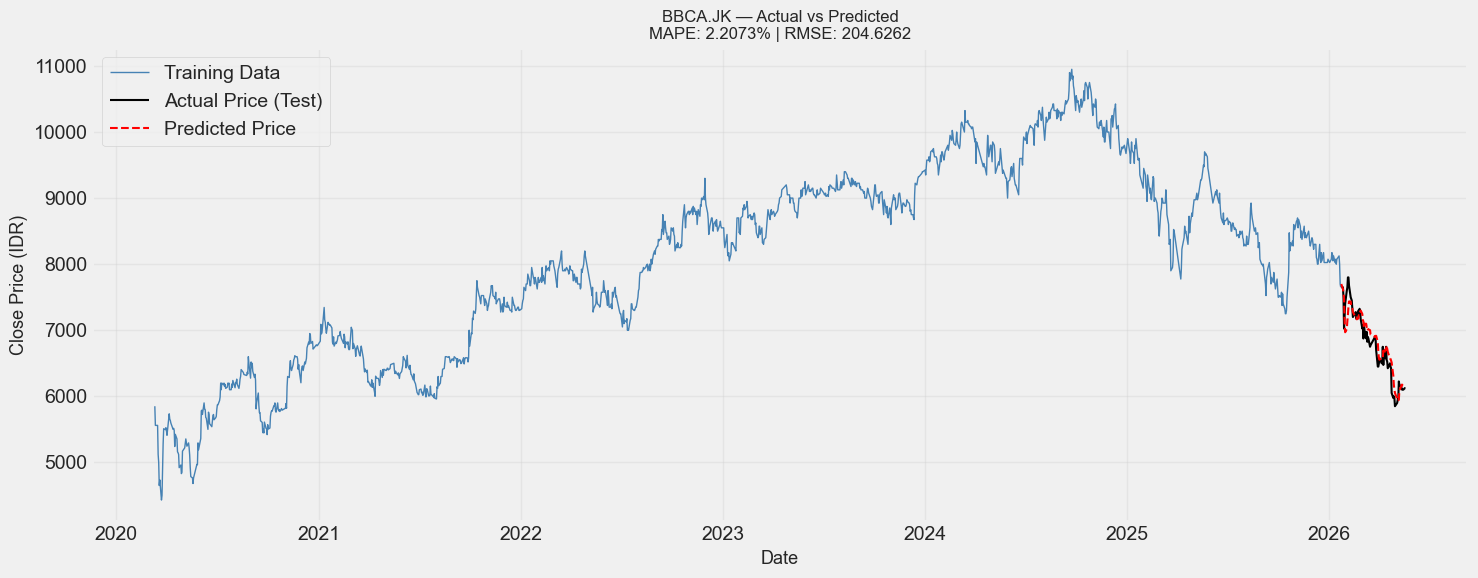

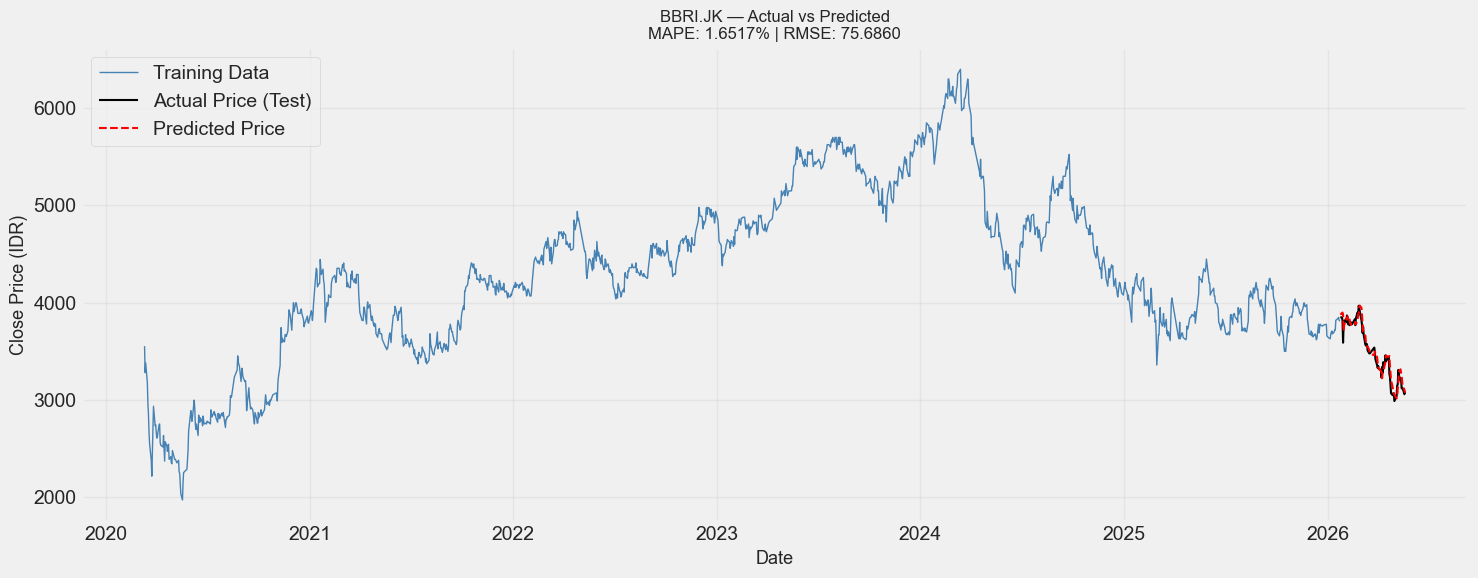

In [5]:
def plot_predictions(result):
    """
    Plot training data + actual vs predicted untuk satu saham.
    Persis seperti plot di Phase 1a, tapi jadi fungsi supaya bisa dipanggil ulang.
    """
    ticker     = result['ticker']
    df         = result['df']
    train_len  = result['train_len']
    predictions = result['predictions']
    y_true     = result['y_true']
    rmse       = result['rmse']
    mape       = result['mape']

    train_plot = df['Close'][:train_len]
    test_dates = df.index[train_len:]

    plt.figure(figsize=(15, 6))
    plt.title(
        f'{ticker} — Actual vs Predicted\n'
        f'MAPE: {mape:.4f}% | RMSE: {rmse:.4f}',
        fontsize=12
    )
    plt.xlabel('Date', fontsize=13)
    plt.ylabel('Close Price (IDR)', fontsize=13)

    plt.plot(train_plot.index, train_plot.values,
             label='Training Data', color='steelblue', linewidth=1)
    plt.plot(test_dates, y_true,
             label='Actual Price (Test)', color='black', linewidth=1.5)
    plt.plot(test_dates, predictions,
             label='Predicted Price', color='red', linewidth=1.5, linestyle='--')

    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Plot BBCA
plot_predictions(result_bbca)

# Plot BBRI
plot_predictions(result_bbri)

---
## Bagian 6 — Ringkasan semua model

Kita bandingkan performa ketiga model sekaligus.

RINGKASAN PERFORMA SEMUA MODEL — PHASE 1 SELESAI
AAPL       MAPE: 1.3418%   RMSE: 4.6048 USD
BBCA.JK    MAPE: 2.2073%   RMSE: 204.6262 IDR
BBRI.JK    MAPE: 1.6517%   RMSE: 75.6860 IDR

Konfigurasi yang dipakai untuk semua saham:
  sequence_length     : 90
  lstm_units          : (128, 64)
  dropout             : 0.1
  batch_size          : 32
  epochs              : 50


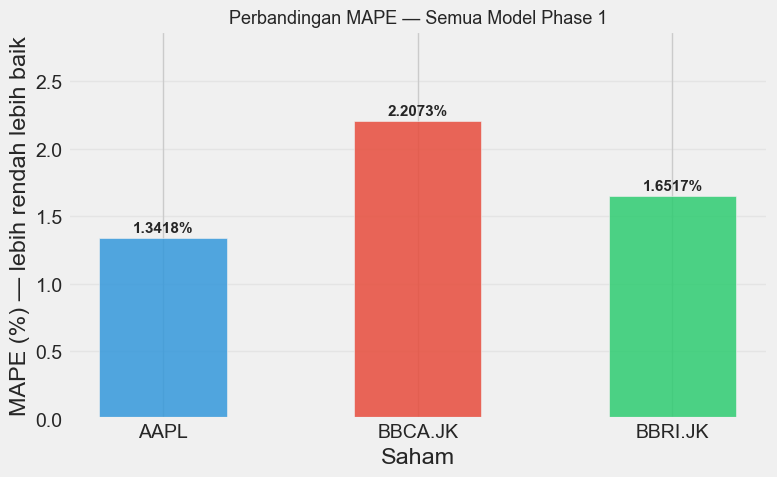


✅ Phase 1 selesai! Semua model tersimpan di folder ../models/

Next: Phase 2 — Buy/Sell Signal Engine


In [6]:
# Performa AAPL dari Phase 1b
aapl_mape = 1.3418
aapl_rmse = 4.6048

summary = [
    {'Saham': 'AAPL',    'MAPE': aapl_mape,              'RMSE': aapl_rmse,              'Mata Uang': 'USD', 'Source': 'Phase 1b'},
    {'Saham': 'BBCA.JK', 'MAPE': result_bbca['mape'],    'RMSE': result_bbca['rmse'],    'Mata Uang': 'IDR', 'Source': 'Phase 1c'},
    {'Saham': 'BBRI.JK', 'MAPE': result_bbri['mape'],    'RMSE': result_bbri['rmse'],    'Mata Uang': 'IDR', 'Source': 'Phase 1c'},
]

summary_df = pd.DataFrame(summary)

print('=' * 60)
print('RINGKASAN PERFORMA SEMUA MODEL — PHASE 1 SELESAI')
print('=' * 60)
for _, row in summary_df.iterrows():
    print(f"{row['Saham']:<10} MAPE: {row['MAPE']:.4f}%   RMSE: {row['RMSE']:.4f} {row['Mata Uang']}")
print('=' * 60)
print(f'\nKonfigurasi yang dipakai untuk semua saham:')
for k, v in BEST_CONFIG.items():
    print(f'  {k:<20}: {v}')

# Visualisasi perbandingan MAPE
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#3498db', '#e74c3c', '#2ecc71']
bars = ax.bar(summary_df['Saham'], summary_df['MAPE'], color=colors, alpha=0.85, width=0.5)

# Tambahkan label angka di atas bar
for bar, mape in zip(bars, summary_df['MAPE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{mape:.4f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Perbandingan MAPE — Semua Model Phase 1', fontsize=13)
ax.set_ylabel('MAPE (%) — lebih rendah lebih baik')
ax.set_xlabel('Saham')
ax.set_ylim(0, max(summary_df['MAPE']) * 1.3)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print('\n✅ Phase 1 selesai! Semua model tersimpan di folder ../models/')
print('\nNext: Phase 2 — Buy/Sell Signal Engine')